In [9]:
import soundfile as sf

In [ ]:
sf.info("channel1.mp3")

channel1.mp3
samplerate: 44100 Hz
channels: 1
duration: 3.482 s
format: MPEG-1/2 Audio [MP3]
subtype: MPEG Layer III [MPEG_LAYER_III]

In [11]:
sf.info("channel2.mp3")

channel2.mp3
samplerate: 44100 Hz
channels: 1
duration: 4.032 s
format: MPEG-1/2 Audio [MP3]
subtype: MPEG Layer III [MPEG_LAYER_III]

In [14]:
s1, sr = sf.read("channel1.mp3", dtype="float32")
s2, sr = sf.read("channel2.mp3", dtype="float32")

In [ ]:
s1, sr = sf.read("channel1.mp3", dtype="float32")
s2, sr = sf.read("channel2.mp3", dtype="float32")

In [15]:
from IPython.display import Audio

In [19]:
Audio(s1, rate=sr)

In [20]:
Audio(s2, rate=sr)

In [60]:
import numpy as np


def mix(s1, s2):
    length = max(len(s1), len(s2))
    s1 = np.pad(s1, (0, length - len(s1)), mode="constant")
    s2 = np.pad(s2, (0, length - len(s2)), mode="constant")
    # Ensure both signals are of the same length
    mixed = s1 + s2
    return s1, s2, mixed

In [66]:
s1, s2, sm = mix(s1, s2)

In [67]:
Audio(s1, rate=sr)

In [68]:
Audio(s2, rate=sr)

In [69]:
Audio(sm, rate=sr)

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as sp
from scipy.io import wavfile
import librosa
import librosa.display

from matplotlib import rcParams

# 设置全局字体（根据系统实际字体名称调整）
rcParams["font.family"] = "Noto Sans CJK JP"  # 简体中文版本
# rcParams['font.family'] = 'Noto Sans CJK TC'  # 繁体中文版本
rcParams["axes.unicode_minus"] = False  # 解决负号显示问题

In [70]:
def compute_stft(signal):
    """计算信号的短时傅里叶变换"""
    stft = librosa.stft(signal, n_fft=1024, hop_length=512)
    return np.abs(stft)

In [71]:
stft1 = compute_stft(s1)
stft2 = compute_stft(s2)
stftm = compute_stft(sm)

In [72]:
ratio1 = stft1 / (stftm + 1e-16)
ratio2 = stft2 / (stftm + 1e-16)

In [75]:
mask = stftm > 0.1

In [76]:
mask

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

In [83]:
np.multiply(*ratio1.shape)

178011

In [105]:
total_bins = np.nonzero(mask)[0].shape

In [118]:
ratio1[mask].max()

29.719341

In [124]:
m = (stft1 + stft2) > stftm

In [125]:
np.nonzero(m)[0].shape

(153068,)

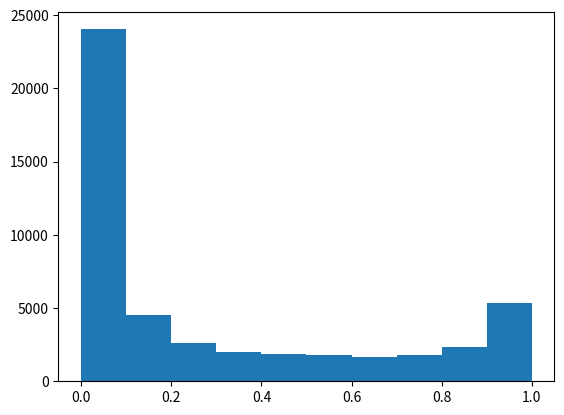

In [108]:
bins1 = plt.hist(ratio1[mask].flatten(), range=[0, 1], bins=10, label="Channel 1 Ratio")

In [115]:
bins1[0].sum()

47866.0

In [112]:
a = bins1[0] / total_bins

In [113]:
a.sum()

0.8566008697363947

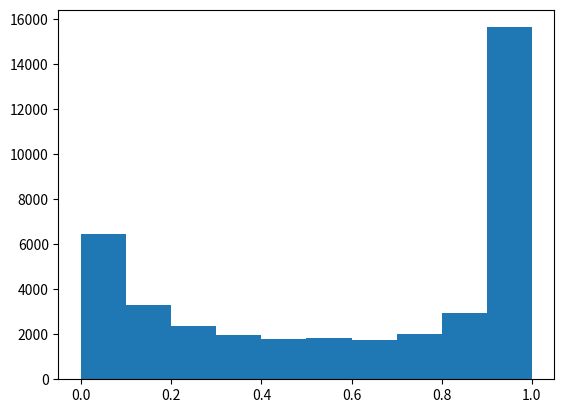

In [110]:
bins2 = plt.hist(ratio2[mask].flatten(), range=[0, 1], bins=10, label="Channel 2 Ratio")

In [111]:
bins2[0] / total_bins

array([0.11589327, 0.05910986, 0.04209095, 0.0350221 , 0.03230194,
       0.03296408, 0.03146084, 0.03579162, 0.05279264, 0.28003364])